Exercício 1

• Uma empresa deseja prever se um funcionário será promovido ou não com
base em algumas características. Você deve treinar e testar um modelo de
Árvore de Decisão para classificar os funcionários em “Promovido” ou “Não
Promovido”.

• Atributos do dataset:

– Idade (anos)

– Anos de Experiência

– Treinamentos Concluídos

– Promovido (0 = Não, 1 = Sim)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv

### CARREGANDO OS DADOS DO DATASET

In [2]:
# Função para carregar dados do CSV
def carregar_dados(arquivo):
    X, y = [], []
    with open(arquivo, 'r') as f:
        leitor = csv.reader(f)
        next(leitor) # pular cabeçalho
        for linha in leitor:
            X.append([float(linha[0]), float(linha[2])]) #idade, treinamentos
            y.append(int(linha[3]))
    return np.array(X), np.array(y)

# Carregando o dataset
X, y = carregar_dados("arvore_decisao_dataset_exercicio_1.csv")
print("Formato dos dados: ", X.shape, y.shape)
print("Primeiras amostras: \n", X[:5], "\nRótulos: ", y[:5])

Formato dos dados:  (25, 2) (25,)
Primeiras amostras: 
 [[25.  1.]
 [28.  2.]
 [30.  3.]
 [32.  2.]
 [35.  4.]] 
Rótulos:  [0 0 1 1 1]


### DEFINIÇÃO DA FUNÇÃO DE ENTROPIA

In [3]:
def entropia(y):
    classes, contagem = np.unique(y, return_counts=True)
    probs = contagem / len(y)
    return -np.sum(probs * np.log2(probs + 1e-9))

# Teste da entropia
print("Entropia [0,0,0,0] ->", entropia([0,0,0,0]))
print("Entropia [0,1,0,1] ->", entropia([0,1,0,1]))

Entropia [0,0,0,0] -> -1.4426951595367387e-09
Entropia [0,1,0,1] -> 0.99999999711461


### DIVISÃO DOS DADOS

In [4]:
def dividir(X, y, feature, limiar):
    esquerda_idx = X[:, feature] <= limiar
    direita_idx = X[:, feature] > limiar
    return X[esquerda_idx], y[esquerda_idx], X[direita_idx], y[direita_idx]

# Testando divisão por idade <= 40

Xe, ye, Xd, yd = dividir(X, y, feature=0, limiar=40)
print("Esquerda: ", ye)
print("Direita: ", yd)

Esquerda:  [0 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1]
Direita:  [0 1 1 0 0 0 0 1 0]


### IMPLEMENTAÇÃO DA ÁRVORE DE DECISÃO

In [5]:
class No:
    def __init__(self, feature=None, limiar=None, esquerda=None, direita=None, valor=None):
        self.feature = feature
        self.limiar = limiar
        self.esquerda = esquerda
        self.direita = direita
        self.valor = valor  # classe se for folha

class ArvoreDecisao:
    def __init__(self, max_profundidade=3, min_amostras=2):
        self.max_profundidade = max_profundidade
        self.min_amostras = min_amostras
        self.raiz = None

    def ajustar(self, X, y):
        self.raiz = self._crescer(X, y, profundidade=0)

    def _crescer(self, X, y, profundidade):
        num_amostras, num_features = X.shape
        num_classes = len(np.unique(y))

        # Condições de parada
        if (profundidade >= self.max_profundidade or
            num_classes == 1 or
            num_amostras < self.min_amostras):
            classe_final = np.bincount(y).argmax()
            return No(valor=classe_final)

        melhor_feature, melhor_limiar, melhor_info = None, None, -1
        melhor_divisao = None

        for feature in range(num_features):
            valores = np.unique(X[:, feature])
            for limiar in valores:
                X_esq, y_esq, X_dir, y_dir = dividir(X, y, feature, limiar)

                if len(y_esq) == 0 or len(y_dir) == 0:
                    continue

                ganho = entropia(y) - (
                    len(y_esq) / num_amostras * entropia(y_esq) +
                    len(y_dir) / num_amostras * entropia(y_dir)
                )

                if ganho > melhor_info:
                    melhor_feature, melhor_limiar, melhor_info = feature, limiar, ganho
                    melhor_divisao = (X_esq, y_esq, X_dir, y_dir)

        if melhor_info == -1:
            classe_final = np.bincount(y).argmax()
            return No(valor=classe_final)

        esquerda = self._crescer(melhor_divisao[0], melhor_divisao[1], profundidade + 1)
        direita = self._crescer(melhor_divisao[2], melhor_divisao[3], profundidade + 1)
        return No(melhor_feature, melhor_limiar, esquerda, direita)

    def prever(self, X):
        return np.array([self._prever_amostra(x, self.raiz) for x in X])

    def _prever_amostra(self, x, no):
        if no.valor is not None:
            return no.valor

        if x[no.feature] <= no.limiar:
            return self._prever_amostra(x, no.esquerda)
        else:
            return self._prever_amostra(x, no.direita)

### TREINANDO A ÁRVORE DE DECISÃO

In [6]:
arvore = ArvoreDecisao(max_profundidade=3)
arvore.ajustar(X, y)

y_pred = arvore.prever(X)
acuracia = np.mean(y_pred == y)
print(f"Acurácia no conjunto de treino: {acuracia*100:.2f}%")

Acurácia no conjunto de treino: 100.00%


### PLOTANDO A FRONTEIRA DE DECISÃO

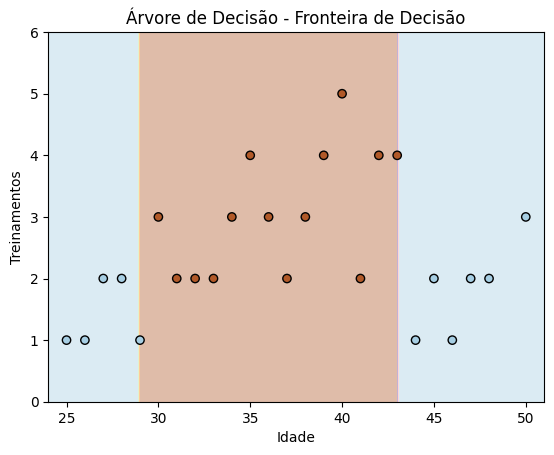

In [7]:
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = arvore.prever(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.Paired)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k", cmap=plt.cm.Paired)
plt.xlabel("Idade")
plt.ylabel("Treinamentos")
plt.title("Árvore de Decisão - Fronteira de Decisão")
plt.show()